## Ejemplo Kmeans


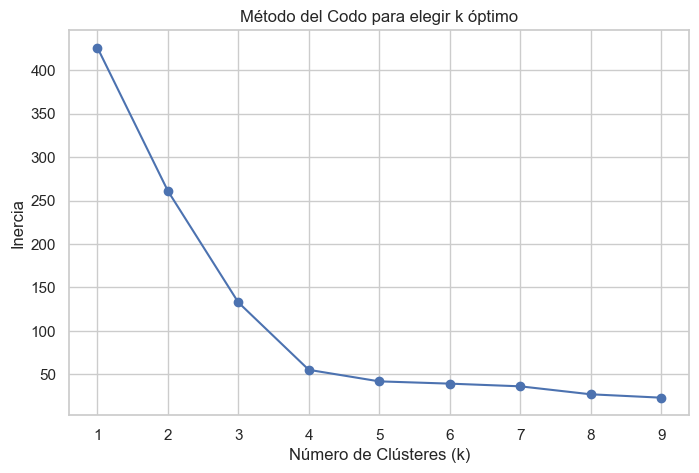

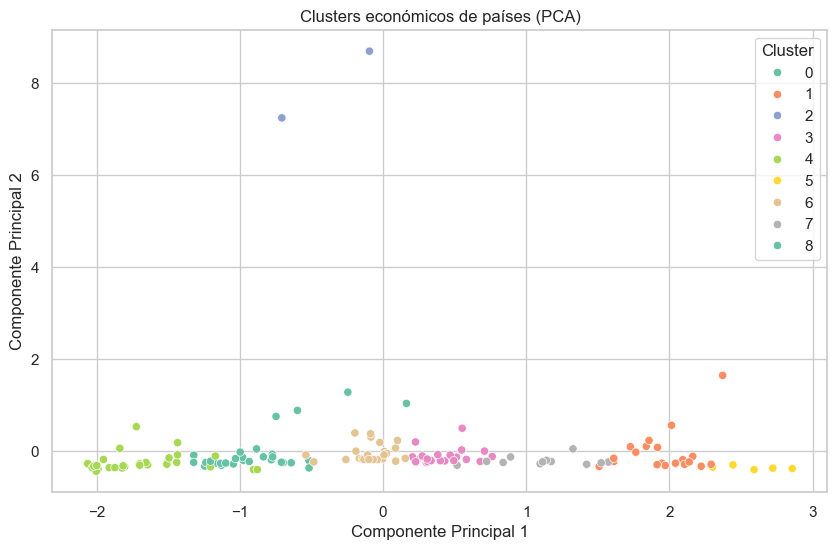

            gdpPercap    lifeExp           pop
cluster                                       
0         2132.311402  59.646080  1.422089e+07
1        33364.949365  79.912250  4.413177e+07
2         3705.662630  68.829500  1.214540e+09
3        10624.203972  74.990870  1.848907e+07
4         2514.963414  47.319964  2.136855e+07
5        44841.666922  79.769800  4.555198e+06
6         4947.882776  71.728261  2.915125e+07
7        21763.595138  76.422083  1.113973e+07
8         4150.913440  68.146250  1.833192e+08


In [8]:
# 📦 Cargar librerías
import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 🎯 Configuración general
RANDOM_STATE = 42
sns.set(style="whitegrid")

# 📥 Función para cargar y preparar datos
def load_gapminder(year=2007):
    df = px.data.gapminder().query(f"year == {year}")
    return df[['country', 'continent', 'gdpPercap', 'lifeExp', 'pop']].copy()

# 🔍 Preprocesamiento
def preprocess_features(df, features):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df[features])
    return X_scaled

# 📈 Método del Codo
def plot_elbow(X_scaled, max_k=10):
    inertia = []
    for k in range(1, max_k):
        kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE).fit(X_scaled)
        inertia.append(kmeans.inertia_)

    plt.figure(figsize=(8, 5))
    plt.plot(range(1, max_k), inertia, marker='o')
    plt.title("Método del Codo para elegir k óptimo")
    plt.xlabel("Número de Clústeres (k)")
    plt.ylabel("Inercia")
    plt.show()

# 🤖 Aplicar K-Means
def apply_kmeans(X_scaled, df, n_clusters=4):
    model = KMeans(n_clusters=n_clusters, random_state=RANDOM_STATE)
    df['cluster'] = model.fit_predict(X_scaled)
    return df, model

# 🧬 Visualización con PCA
def plot_pca_clusters(X_scaled, df):
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    df['pca1'], df['pca2'] = X_pca[:, 0], X_pca[:, 1]

    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df, x='pca1', y='pca2', hue='cluster', palette='Set2')
    plt.title("Clusters económicos de países (PCA)")
    plt.xlabel("Componente Principal 1")
    plt.ylabel("Componente Principal 2")
    plt.legend(title="Cluster")
    plt.show()

# 🌍 Mapa mundial de clusters
def plot_cluster_map(df):
    fig = px.choropleth(
        df,
        locations="country",
        locationmode="country names",
        color="cluster",
        hover_name="country",
        color_continuous_scale="viridis",
        title="Mapa Mundial: Clusters Económicos de Países (K-Means)"
    )
    fig.show()

# 📊 Análisis de medias por cluster
def show_cluster_summary(df):
    return df.groupby('cluster')[['gdpPercap', 'lifeExp', 'pop']].mean()

# 🧪 Ejecución completa
if __name__ == "__main__":
    df = load_gapminder()
    features = ['gdpPercap', 'lifeExp', 'pop']
    X_scaled = preprocess_features(df, features)

    plot_elbow(X_scaled)
    df, model = apply_kmeans(X_scaled, df, n_clusters=9)
    plot_pca_clusters(X_scaled, df)
    plot_cluster_map(df)
    summary = show_cluster_summary(df)
    print(summary)

## Ejemplo KMeans 2


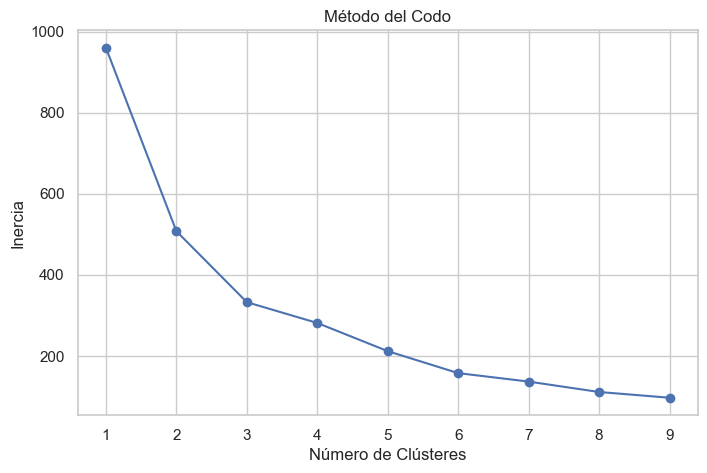

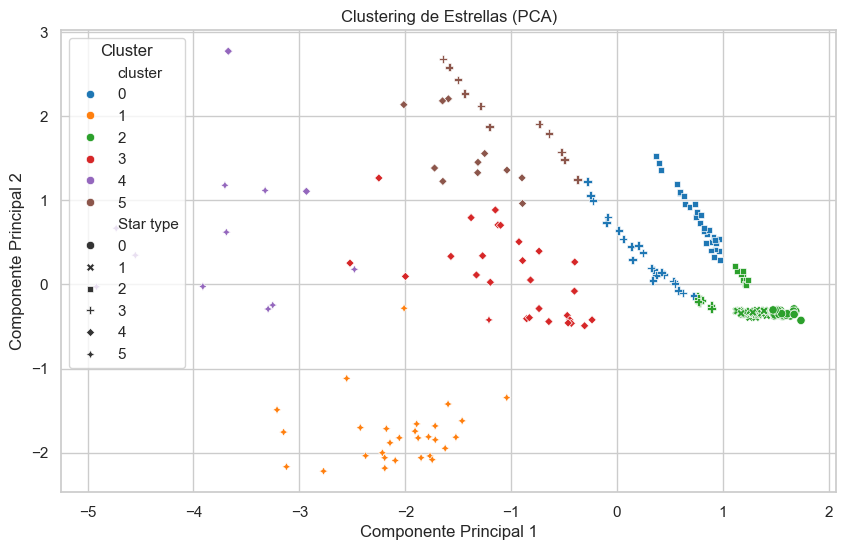

In [9]:
# 📦 Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# 🎯 Configuración global
RANDOM_STATE = 42
sns.set(style="whitegrid")

# 📥 Cargar datos
def load_star_data(path='6 class.csv'):
    df = pd.read_csv(path)
    return df

# 🧹 Preprocesamiento
def scale_features(df, features):
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df[features])
    return X_scaled

# 🔍 Método del Codo
def plot_elbow(X_scaled, max_k=10):
    inertia = []
    for k in range(1, max_k):
        model = KMeans(n_clusters=k, random_state=RANDOM_STATE)
        model.fit(X_scaled)
        inertia.append(model.inertia_)

    plt.figure(figsize=(8, 5))
    plt.plot(range(1, max_k), inertia, marker='o')
    plt.title("Método del Codo")
    plt.xlabel("Número de Clústeres")
    plt.ylabel("Inercia")
    plt.grid(True)
    plt.show()

# 🤖 Clustering con K-Means
def apply_kmeans(X_scaled, df, n_clusters=6):
    model = KMeans(n_clusters=n_clusters, random_state=RANDOM_STATE)
    df['cluster'] = model.fit_predict(X_scaled)
    return df, model

# 🧬 Visualización PCA
def plot_pca_clusters(X_scaled, df, label_col='Star type'):
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)
    df['pca1'], df['pca2'] = X_pca[:, 0], X_pca[:, 1]

    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        data=df,
        x='pca1', y='pca2',
        hue='cluster',
        style=label_col,
        palette='tab10'
    )
    plt.title("Clustering de Estrellas (PCA)")
    plt.xlabel("Componente Principal 1")
    plt.ylabel("Componente Principal 2")
    plt.legend(title="Cluster")
    plt.show()

# 🧪 Pipeline completo
def run_pipeline():
    df = load_star_data()
    features = ['Temperature (K)', 'Luminosity(L/Lo)', 'Radius(R/Ro)', 'Absolute magnitude(Mv)']
    X_scaled = scale_features(df, features)
    
    plot_elbow(X_scaled)
    
    df, model = apply_kmeans(X_scaled, df, n_clusters=6)
    plot_pca_clusters(X_scaled, df)

    return df

# 🚀 Ejecutar
if __name__ == "__main__":
    df_result = run_pipeline()

In [13]:
data=load_star_data(path='6 class.csv')

<Axes: xlabel='Star type,Star color,Spectral Class'>

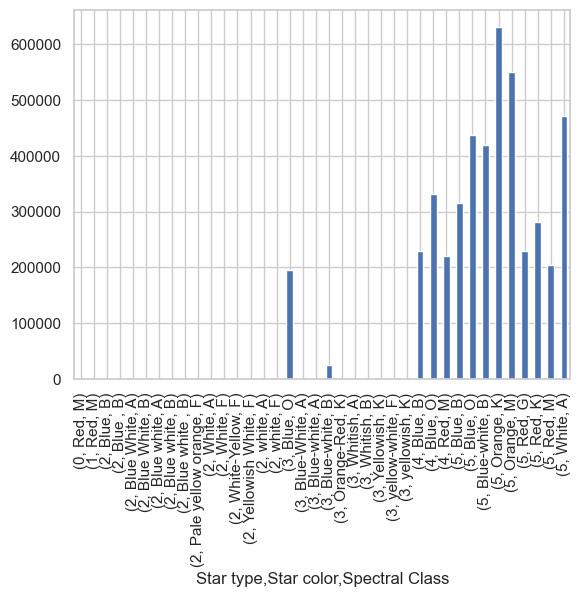

In [21]:
data.groupby(['Star type', 'Star color', 'Spectral Class'])['Luminosity(L/Lo)'].mean().plot(kind='bar')

In [22]:
data

,Temperature (K),Luminosity(L/Lo),Radius(R/Ro),Absolute magnitude(Mv),Star type,Star color,Spectral Class
0,3068,0.002400,0.1700,16.12,0,Red,M
1,3042,0.000500,0.1542,16.60,0,Red,M
2,2600,0.000300,0.1020,18.70,0,Red,M
3,2800,0.000200,0.1600,16.65,0,Red,M
4,1939,0.000138,0.1030,20.06,0,Red,M
...,...,...,...,...,...,...,...
235,38940,374830.000000,1356.0000,-9.93,5,Blue,O
236,30839,834042.000000,1194.0000,-10.63,5,Blue,O
237,8829,537493.000000,1423.0000,-10.73,5,White,A
238,9235,404940.000000,1112.0000,-11.23,5,White,A
